# Import:

In [2]:
from Normalization import split
from Models import baselines, gears_predict
from Metrics import performance_metrics

import numpy as np
import anndata as ad
import scanpy as sc
import os
import pickle
from gears import utils, pertdata

/storage/mi/sommereg03/vsp/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
grn_file = "doro_abcd_only"
names = ["Norman19"]#,"Replogle22"]
models = ["experimental","pGRiNS"]#,"mixed"] # Mixed will have for each pert i% cells of pGRiNS and (1-i)% cells of exp.


# Prepare Data:

In [4]:
data = {}
for name in names:
    data[name] = {}
    for model in models:
        data[name][model] = {}
    data[name]["experimental"]["adata"] = sc.read_h5ad(f"../../Data/Experimental/{name}/perturb_norm_subset_{grn_file}.h5ad")

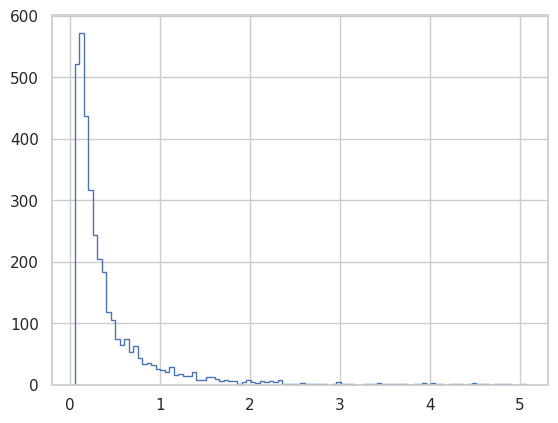

In [26]:
import matplotlib.pyplot as plt
plt.stairs(*np.histogram(np.mean(data[name]["experimental"]["adata"].layers["log1p"],axis=0),bins=100))

In [5]:

pgrins_full = sc.read_h5ad(f"../../Data/Projects/{grn_file}/001/perturb_norm_pert.h5ad")
for name in names:
    data[name]["pGRiNS"]["adata"] = pgrins_full[pgrins_full.obs["perturbation"].isin(data[name]["experimental"]["adata"].obs["perturbation"]),sorted(list(set(data[name]["experimental"]["adata"].var_names)&set(pgrins_full.var_names)))]
    data[name]["pGRiNS"]["adata"].obs["cell_line"] = f"syn_{list(data[name]["experimental"]["adata"].obs["cell_line"])[0]}"
    data[name]["experimental"]["adata"] = data[name]["experimental"]["adata"][:,sorted(list(set(data[name]["experimental"]["adata"].var_names)&set(data[name]["pGRiNS"]["adata"].var_names)))]


## Remove perturbations not in GO graph:

In [6]:
def get_bad_perts(norm_data,name) -> list[str]:
    """
    Retrieves a list of perturbations from the dataset that are not found in the GO graph of gears and must therefore be skipped.

    Parameters:
    -----------
    norm_data : anndata
        An anndata object containing the normalized data.
    filename : str
        The name of the dataset.
    
    Returns:
    --------
    not_in_go_pert : list[str]
        A list of perturbation names that are not in the GO graph.
    """

    # For GEARS:
    os.makedirs(f"../../Data/Experimental/{name}/experimental",exist_ok=True)
    pert_data = pertdata.PertData(f"../../Data/Experimental/{name}/experimental")
    pert_data.set_pert_genes()
    with open(f"../../Data/Experimental/{name}/experimental/gene2go_all.pkl", 'rb') as f:
        gene2go = pickle.load(f)
    with open(f"../../Data/Experimental/{name}/experimental/essential_all_data_pert_genes.pkl", 'rb') as f:
        essential_genes = pickle.load(f)
    gene2go = {g: gene2go[g] for g in essential_genes if g in gene2go}

    pert_names = np.unique(list(gene2go.keys()))

    not_in_go_pert = np.array(norm_data.obs[norm_data.obs.condition.apply(lambda x:not utils.filter_pert_in_go(x,pert_names))].condition.unique())
    return not_in_go_pert

In [7]:
for name in names:
    bad_perts = get_bad_perts(data[name]["experimental"]["adata"],name) # Get perturbations that need to be skipped
    for model in models:
        data[name][model]["pert_indices"] = (split.ctrl_pert_split_dataset(data[name][model]["adata"],bad_perts))

Found local copy...
Found local copy...


In [8]:
for name in names:
    if not os.path.exists(f"../../Data/Projects/{grn_file}/001/perturb_norm_subset_{name}.h5ad"):
        data[name]["pGRiNS"]["adata"].write_h5ad(f"../../Data/Projects/{grn_file}/001/perturb_norm_subset_{name}.h5ad")

## Create train/test split:

In [9]:
no_iterations = 5
for name in names:
    for it in range(no_iterations):
        os.makedirs(f"../../Data/Experimental/{name}/Splits",exist_ok=True)
    ctrl_i_vec, pert_i_dict = data[name]["experimental"]["pert_indices"]
    if False in [os.path.isfile(f"../../Data/Experimental/{name}/Splits/split_{it}.pickle") for it in range(no_iterations)]: # If one cv_it model has not been generated for the current file
        print("Creating splits")
        splits = split.cross_validate_split_blockwise(data[name]["experimental"]["adata"], pert_i_dict, name, need_val=False, no_iterations=no_iterations) # Possible that data_loader in GEARS doesnt work if need_val=False
        

# Train Models:
Done in separate file(s)

## Make predictions:

In [ ]:
# GEARS:
for name in names:
    for model in models:
        if False in [os.path.isfile(f"../../Data/Experimental/{name}/{model}/Models/GEARS/cv_{it}/model.pt") for it in range(no_iterations)]: # If one cv_it model has not been generated for the current file
            raise Exception(f"GEARS has not been trained on at least one split for the dataset {name}/{model}. Please execute\nnohup python3 -u train_gears_parallel.py {name} {model} {grn_file} {no_iterations} > ../../Logs/GEARS_{name}_{model}_out.log 2>&1 &\non the cluster.")        
        print(f"{name}, {model}:")
        for it in range(no_iterations):
            print(f"\t({it+1}/{no_iterations})")
            splits = pickle.load(open(f"../../Data/Experimental/{name}/Splits/split_{it}.pickle",'rb'))
            train_perts = list([p[:-5] if "+ctrl" in p else p.replace("+","_") for p in splits["train"]])
            val_perts = list([p[:-5] if "+ctrl" in p else p.replace("+","_") for p in splits["val"]])
            test_perts = list([p[:-5] if "+ctrl" in p else p.replace("+","_") for p in splits["test"]])

            gears_dict = gears_predict.predict_gears(it,test_perts,name,model)

Found local copy...


Found local copy...
These perturbations are not in the GO graph and their perturbation can thus not be predicted
[]
Local copy of pyg dataset is detected. Loading...
Done!
Creating dataloaders....
Done!


'Series' object has no attribute 'nonzero' ignored


Found local copy...
Found local copy...
Found local copy...
These perturbations are not in the GO graph and their perturbation can thus not be predicted
[]
Local copy of pyg dataset is detected. Loading...
Done!
Creating dataloaders....
Done!


'Series' object has no attribute 'nonzero' ignored


...

Found local copy...
Found local copy...
Found local copy...
These perturbations are not in the GO graph and their perturbation can thus not be predicted
[]
Local copy of pyg dataset is detected. Loading...
Done!
Creating dataloaders....
Done!


'Series' object has no attribute 'nonzero' ignored


Found local copy...
Found local copy...
Found local copy...
These perturbations are not in the GO graph and their perturbation can thus not be predicted
[]
Local copy of pyg dataset is detected. Loading...
Done!
Creating dataloaders....
Done!


'Series' object has no attribute 'nonzero' ignored


Found local copy...


# Evaluate Models:

In [ ]:
# Split perturbations into train/validate/test datasets:
for name in names:
    for model in models:
        if False in [os.path.isfile(f"../../Data/Experimental/{name}/{model}/Models/GEARS/cv_{it}/model.pt") for it in range(no_iterations)]: # If one cv_it model has not been generated for the current file
            raise Exception(f"GEARS has not been trained on at least one split for the dataset {name}/{model}. Please execute\nnohup python3 -u train_gears_parallel.py {name} {model} {grn_file} {no_iterations} > ../../Logs/GEARS_{name}_{model}_out.log 2>&1 &\non the cluster.")        

    ctrl_i_vec, pert_i_dict = data[name]["experimental"]["pert_indices"]
    all_iterations = []
    deg_all_it = []
    for it in range(no_iterations):
        print(f"\t({it+1}/{no_iterations})")

        splits = pickle.load(open(f"../../Data/Experimental/{name}/Splits/split_{it}.pickle",'rb'))
        train_perts = list([p[:-5] if "+ctrl" in p else p.replace("+","_") for p in splits["train"]])
        val_perts = list([p[:-5] if "+ctrl" in p else p.replace("+","_") for p in splits["val"]])
        test_perts = list([p[:-5] if "+ctrl" in p else p.replace("+","_") for p in splits["test"]])
        
        td_index_dict, gt_index_dict = baselines.td_gt_split(pert_i_dict,test_perts) # TD/GT split
        
        # Generate baselines:
        print("Technical Duplicate")
        mu_td_dict, mu_gt_dict = baselines.technical_duplicate(data[name]["experimental"]["adata"],td_index_dict,gt_index_dict) # Positive control
        print("Control Baseline")
        mu_unperturbed = baselines.control_baseline(data[name]["experimental"]["adata"],ctrl_i_vec) # Negative control
        #print("Informed Model")
        #informed_dict = baselines.informed_model(data[name]["experimental"]["adata"],train_perts=train_perts,test_perts=test_perts,pert_i_dict=pert_i_dict,control_baseline=mu_unperturbed)
        print("Mean Baseline")
        mu_all = baselines.mean_baseline(data[name]["experimental"]["adata"],pert_i_dict,train_perts) # Naive model
        print("Interpolated Duplicate")
        id_dict = baselines.interpolated_duplicate(data[name]["experimental"]["adata"],mu_td_dict,mu_all,td_index_dict) # Positive control
        
        # Predict using the models:
        print("GEARS")
        gears_dicts = [gears_predict.predict_gears(it,test_perts,name,model) for model in models]

        
        # Compute simple metrics (shape: model x metric x test_pert):
        print("Computing Metrics")
        model_list = [mu_unperturbed,mu_all,mu_td_dict,id_dict,*gears_dicts]#,informed_dict]
        metric_matrix = performance_metrics.compute_metrics_all(mu_gt_dict, model_list, mu_unperturbed)

        # Compute weighted metrics:
        weight_dict = performance_metrics.get_weights(data[name]["experimental"]["adata"],mu_gt_dict,td_index_dict)
        weight_metric_matrix = performance_metrics.compute_metrics_all(mu_gt_dict, model_list, mu_all,weight_dict = weight_dict)

        all_iterations.append(np.concatenate([metric_matrix,weight_metric_matrix],axis=1))
       
    # Erstelle 4d_array
    max_perts = max(m.shape[2] for m in all_iterations)
    no_models = all_iterations[0].shape[0]
    no_metrics = all_iterations[0].shape[1]
    no_iters = len(all_iterations)
    fourD_metric_matrix = np.full((no_iters, no_models, no_metrics, max_perts), np.nan)

    for it, matrix in enumerate(all_iterations):
        curr_perts = matrix.shape[2]
        fourD_metric_matrix[it, :, :, :curr_perts] = matrix
        
    #for it in all_iterations: # <- test_pert will only have the same shape for all iterations if the number of perturbations is divisible by no_iterations
    #    print(it.shape,it)

(1/5)
Technical Duplicate
Control Baseline
Mean Baseline
Interpolated Duplicate
GEARS
Computing Metrics
(2/5)
Technical Duplicate
Control Baseline
Mean Baseline
Interpolated Duplicate
GEARS
Computing Metrics
(3/5)
Technical Duplicate
Control Baseline
Mean Baseline
Interpolated Duplicate
GEARS
Computing Metrics
(4/5)
Technical Duplicate
Control Baseline
Mean Baseline
Interpolated Duplicate
GEARS
Computing Metrics
(5/5)
Technical Duplicate
Control Baseline
Mean Baseline
Interpolated Duplicate
GEARS
Computing Metrics


In [15]:
# If a submodule is changed, it needs to be reloaded
import importlib
importlib.reload(split)
importlib.reload(baselines)
importlib.reload(performance_metrics)
importlib.reload(gears_predict)

<module 'Models.gears_predict' from '/home/mi/sommereg03/bsc_thesis_pGRiNS/Analysis/ml_eval/Models/gears_predict.py'>

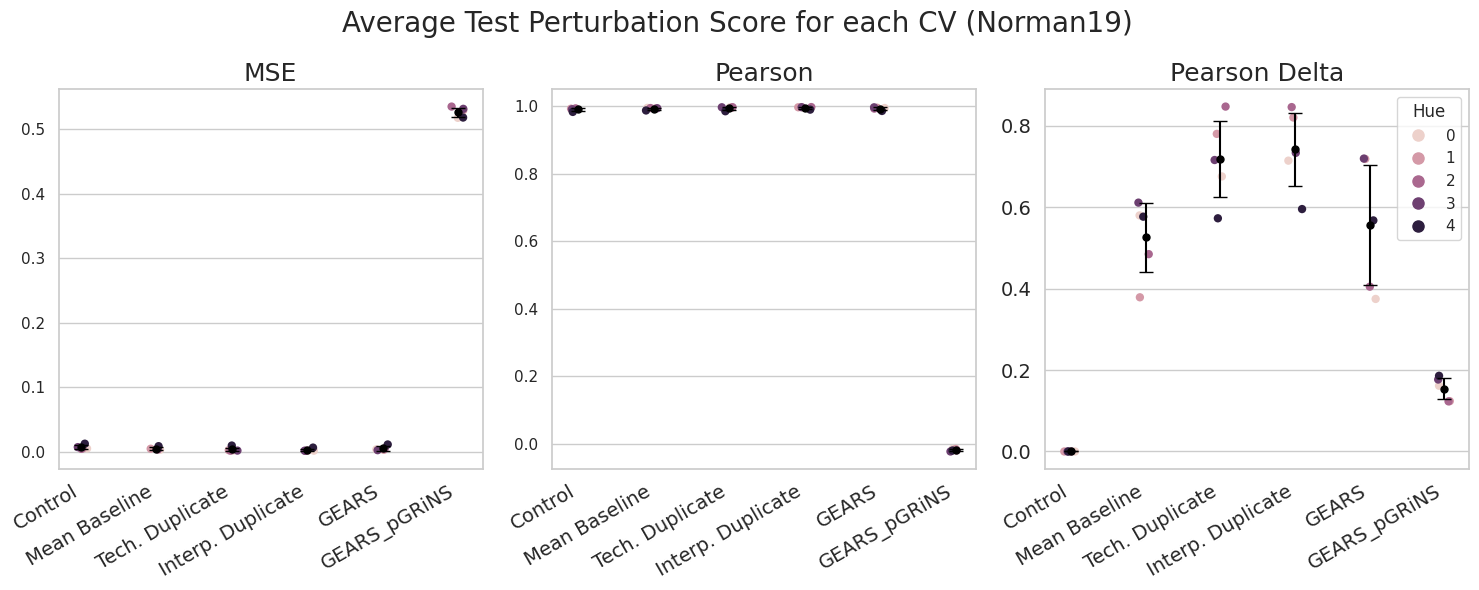

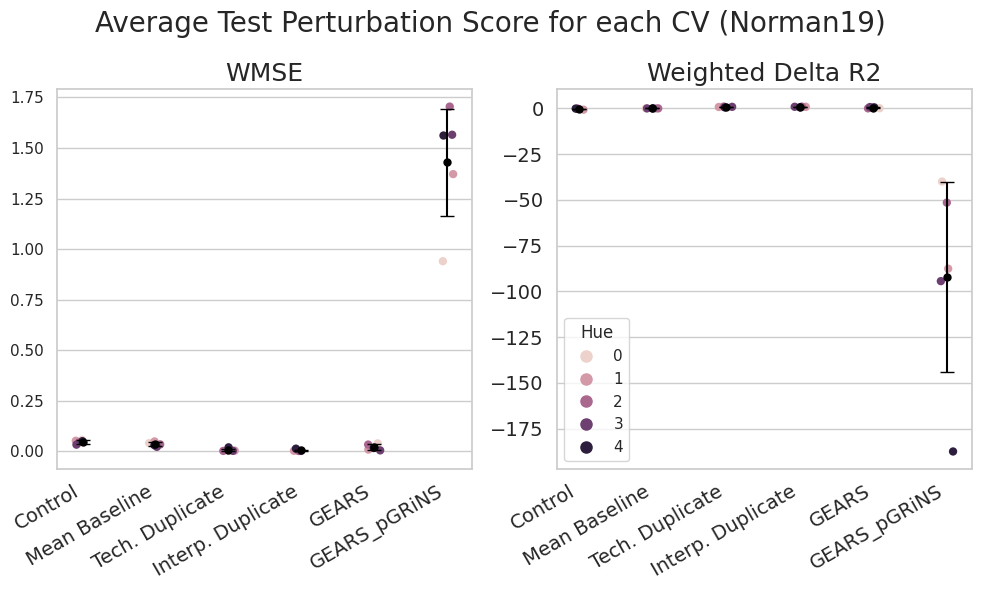

'\n# Plot for each CV block\nperformance_metrics.plot_cv_block(\n    filename = filename,\n    fourD_metric_matrix=fourD_metric_matrix,\n    model_list=model_list,\n) \n'

In [17]:

importlib.reload(performance_metrics)
# Plotting results
model_list = ["Control", "Mean Baseline", "Tech. Duplicate", "Interp. Duplicate", "GEARS","GEARS_pGRiNS"]#,"Informed Model"]
"""
# Distribution over Perturbations
performance_metrics.plot_metrics(
    filename = filename,
    fourD_metric_matrix=fourD_metric_matrix,
    model_list=model_list,
    num_block=0,
    mode="all", 
    add_hue = False,
)
"""
# Distribution over CV blocks
performance_metrics.plot_metrics(
    filename = names[0],
    fourD_metric_matrix=fourD_metric_matrix,
    model_list=model_list,
    num_block=0,
    mode="iters",
    add_hue = True
)

performance_metrics.plot_metrics(
    filename = names[0],
    fourD_metric_matrix=fourD_metric_matrix[:,:,3:,:],
    model_list=model_list,
    num_block=0,
    mode="iters",
    add_hue = True,
    metric_names=["WMSE","Weighted Delta R2"]
)
"""
# Plot for each CV block
performance_metrics.plot_cv_block(
    filename = filename,
    fourD_metric_matrix=fourD_metric_matrix,
    model_list=model_list,
) 
"""

Plot training and validation MSE per epoch

    Epoch  Train Overall MSE  Validation Overall MSE  Gap (Validation - Train)
0       1            0.00452                 0.00452                       0.0
1       2            0.00256                 0.00256                       0.0
2       3            0.00202                 0.00202                       0.0
3       4            0.00158                 0.00158                       0.0
4       5            0.00146                 0.00146                       0.0
5       6            0.00144                 0.00144                       0.0
6       7            0.00144                 0.00144                       0.0
7       8            0.00144                 0.00144                       0.0
8       9            0.00146                 0.00146                       0.0
9      10            0.00144                 0.00144                       0.0
10     11            0.00144                 0.00144                       0.0
11     12            0.00144                 0.00144

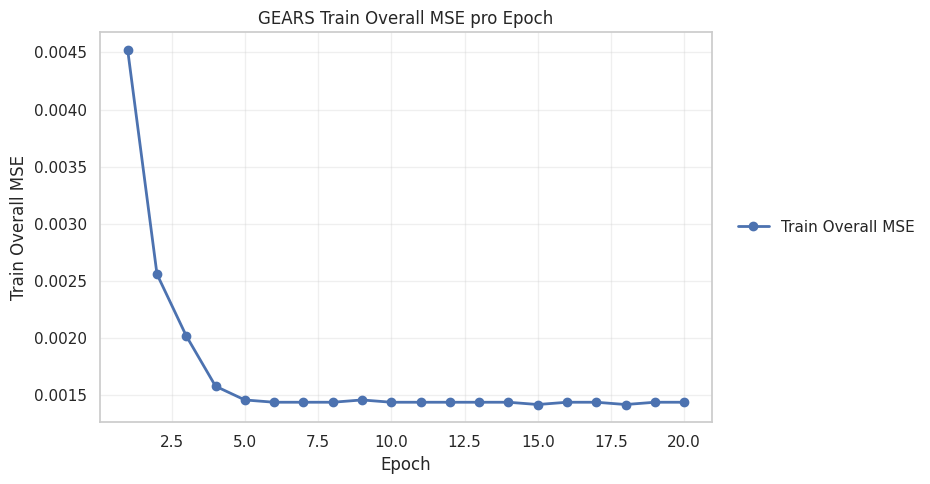

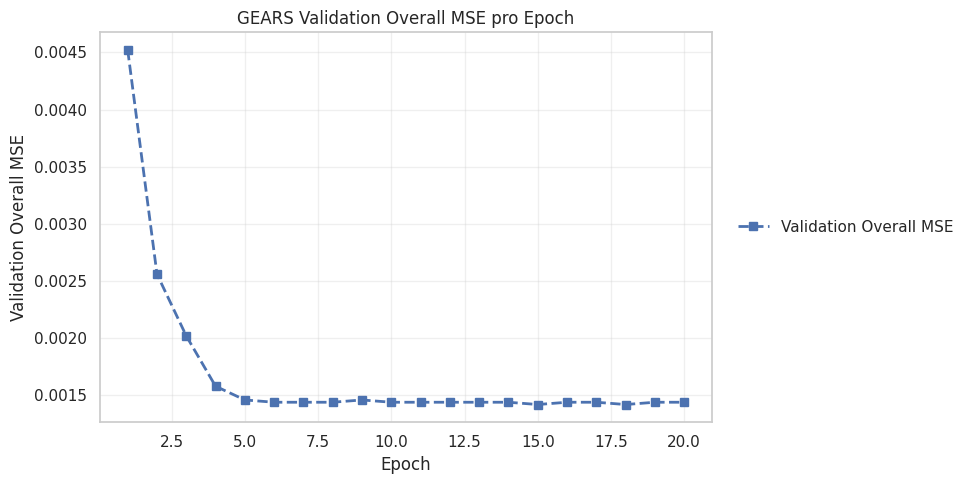

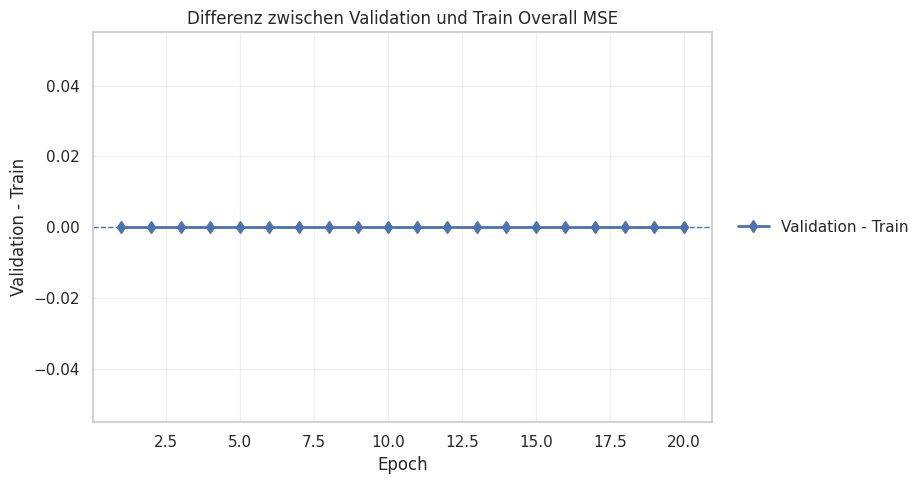

In [ ]:
import re

logfile = "Models/GEARS_NormanWeissman2019_filtered_out.log"

pattern = re.compile(
    r"Epoch\s+(\d+):\s+Train Overall MSE:\s+([0-9.eE+-]+)\.?\s+Validation Overall MSE:\s+([0-9.eE+-]+)\.?"
)


rows = []

with open(logfile, "r") as f:
    for line in f:
        match = pattern.search(line)
        if match:
            epoch = int(match.group(1))
            train_mse = float(match.group(2).rstrip("."))
            val_mse = float(match.group(3).rstrip("."))
            rows.append((epoch, train_mse, val_mse))

if not rows:
    raise ValueError("Keine passenden 'Train Overall MSE / Validation Overall MSE'-Zeilen im Log gefunden.")


df = pd.DataFrame(rows, columns=["Epoch", "Train Overall MSE", "Validation Overall MSE"])

df_mean = (
    df.groupby("Epoch", as_index=False)
      .mean()
      .sort_values("Epoch")
)

df_mean["Gap (Validation - Train)"] = (
    df_mean["Validation Overall MSE"] - df_mean["Train Overall MSE"]
)

print(df_mean)

# Plot 1: Train Overall MSE:
fig1, ax1 = plt.subplots(figsize=(9, 5))

ax1.plot(
    df_mean["Epoch"],
    df_mean["Train Overall MSE"],
    marker="o",
    linewidth=2,
    label="Train Overall MSE"
)

ax1.set_title("GEARS Train Overall MSE pro Epoch")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Train Overall MSE")
ax1.grid(alpha=0.3)

ax1.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

plt.tight_layout()
plt.subplots_adjust(right=0.8)
plt.show()

# Plot 2: Validation Overall MSE:
fig2, ax2 = plt.subplots(figsize=(9, 5))

ax2.plot(
    df_mean["Epoch"],
    df_mean["Validation Overall MSE"],
    marker="s",
    linewidth=2,
    linestyle="--",
    label="Validation Overall MSE"
)

ax2.set_title("GEARS Validation Overall MSE pro Epoch")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Validation Overall MSE")
ax2.grid(alpha=0.3)

ax2.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

plt.tight_layout()
plt.subplots_adjust(right=0.8)
plt.show()



    Epoch  Train Overall MSE  Validation Overall MSE  Gap (Validation - Train)
0       1            0.00494                 0.00494                       0.0
1       2            0.00368                 0.00368                       0.0
2       3            0.00244                 0.00244                       0.0
3       4            0.00184                 0.00184                       0.0
4       5            0.00170                 0.00170                       0.0
5       6            0.00164                 0.00164                       0.0
6       7            0.00166                 0.00166                       0.0
7       8            0.00166                 0.00166                       0.0
8       9            0.00166                 0.00166                       0.0
9      10            0.00166                 0.00166                       0.0
10     11            0.00168                 0.00168                       0.0
11     12            0.00166                 0.00166

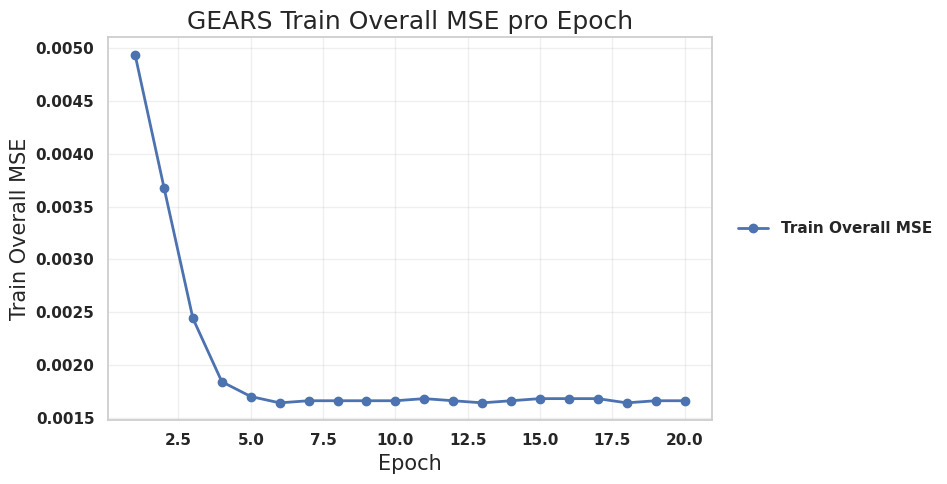

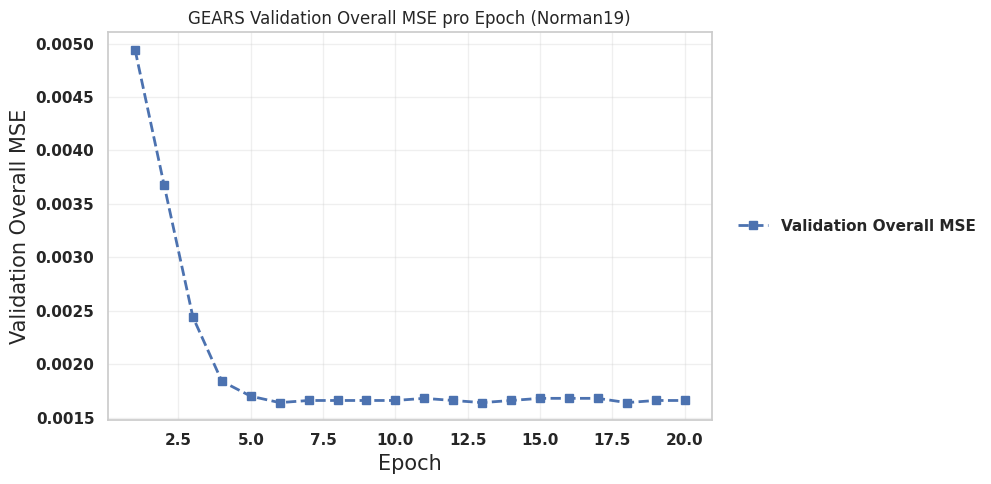

In [ ]:
import re
import pandas as pd
import matplotlib.pyplot as plt

logfile = "Models/GEARS_NormanWeissman2019_filtered_out.log"

pattern = re.compile(
    r"Epoch\s+(\d+):\s+Train Overall MSE:\s+([0-9.eE+-]+)\.?\s+Validation Overall MSE:\s+([0-9.eE+-]+)\.?"
)


rows = []

with open(logfile, "r") as f:
    for line in f:
        match = pattern.search(line)
        if match:
            epoch = int(match.group(1))
            train_mse = float(match.group(2).rstrip("."))
            val_mse = float(match.group(3).rstrip("."))
            rows.append((epoch, train_mse, val_mse))

if not rows:
    raise ValueError("Keine passenden 'Train Overall MSE / Validation Overall MSE'-Zeilen im Log gefunden.")


df = pd.DataFrame(rows, columns=["Epoch", "Train Overall MSE", "Validation Overall MSE"])

df_mean = (
    df.groupby("Epoch", as_index=False)
      .mean()
      .sort_values("Epoch")
)

df_mean["Gap (Validation - Train)"] = (
    df_mean["Validation Overall MSE"] - df_mean["Train Overall MSE"]
)

print(df_mean)

# Plot 1: Train Overall MSE:
fig1, ax1 = plt.subplots(figsize=(9, 5))

ax1.plot(
    df_mean["Epoch"],
    df_mean["Train Overall MSE"],
    marker="o",
    linewidth=2,
    label="Train Overall MSE"
)

ax1.set_title("GEARS Train Overall MSE pro Epoch",fontsize=18)
ax1.set_xlabel("Epoch",fontsize=15)
ax1.set_ylabel("Train Overall MSE",fontsize=15)
ax1.grid(alpha=0.3)

ax1.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

plt.tight_layout()
plt.subplots_adjust(right=0.8)
plt.show()

# Plot 2: Validation Overall MSE:
fig2, ax2 = plt.subplots(figsize=(9, 5))

ax2.plot(
    df_mean["Epoch"],
    df_mean["Validation Overall MSE"],
    marker="s",
    linewidth=2,
    linestyle="--",
    label="Validation Overall MSE"
)

ax2.set_title("GEARS Validation Overall MSE pro Epoch (Norman19)")
ax2.set_xlabel("Epoch",fontsize=15)
ax2.set_ylabel("Validation Overall MSE",fontsize=15)
ax2.grid(alpha=0.3)

ax2.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

plt.tight_layout()
plt.subplots_adjust(right=0.8)
plt.show()



# Reload Submodules: